## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import joblib
import json

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.metrics.cluster import contingency_matrix
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.utils.parallel import Parallel, delayed
from scipy.stats import randint
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR   = os.path.abspath("..")
DATA_DIR   = os.path.join(BASE_DIR, "data")
PLOTS_DIR  = os.path.join(BASE_DIR, "plots")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(PLOTS_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

RANDOM_STATE = 42

## 2. Load Data


In [2]:
X_raw = pd.read_csv(os.path.join(DATA_DIR, "executions_features_raw.csv")).reset_index(drop=True)
meta  = pd.read_csv(os.path.join(DATA_DIR, "executions_clustered.csv")).reset_index(drop=True)
holdout_df = pd.read_csv(os.path.join(DATA_DIR, "holdout_programs.csv"))
holdout_programs = set(holdout_df["program_id"].astype(str))

assert len(X_raw) == len(meta), "Row mismatch between features and metadata"
print(f"Feature matrix : {X_raw.shape}")
print(f"Total programs : {meta['program_id'].nunique()}")
print(f"Holdout programs : {len(holdout_programs)}")

X_raw["cluster"] = meta["cluster"].values.astype(int)
y_pattern  = meta["pattern"].values
y_severity = meta["severity"].values

le_pattern  = LabelEncoder().fit(y_pattern)
le_severity = LabelEncoder().fit(y_severity)
y_pattern_enc  = le_pattern.transform(y_pattern)
y_severity_enc = le_severity.transform(y_severity)

joblib.dump(le_pattern,  os.path.join(MODELS_DIR, "le_pattern.joblib"))
joblib.dump(le_severity, os.path.join(MODELS_DIR, "le_severity.joblib"))
print(f"Encoded targets: {len(np.unique(y_pattern_enc))} pattern classes, {len(np.unique(y_severity_enc))} severity classes")


Feature matrix : (9400, 23)
Total programs : 2000
Holdout programs : 400
Encoded targets: 10 pattern classes, 3 severity classes


## 3. Class Balance Check

Visualise cluster sizes before training. Heavy imbalance justifies
`class_weight='balanced'` in Random Forest and `scale_pos_weight` in XGBoost.


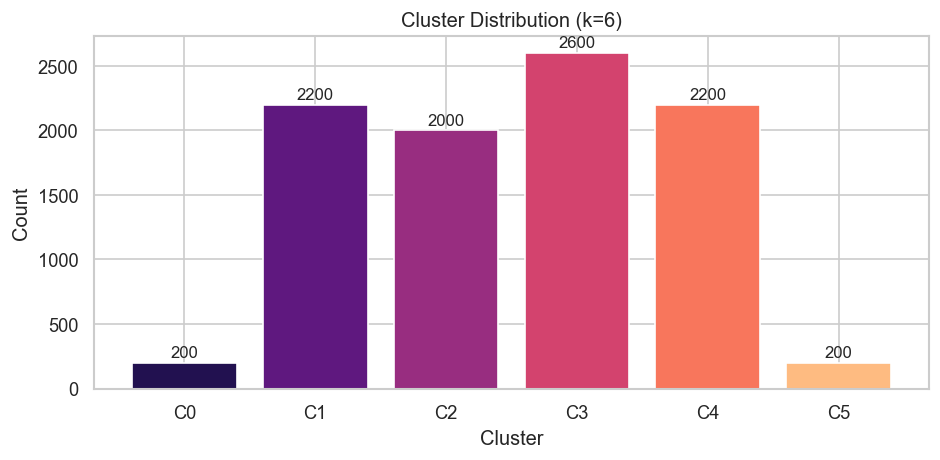

In [3]:
cluster_labels = meta["cluster"].values.astype(int)
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
FINAL_K = len(cluster_counts)                                

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [f"C{i}" for i in cluster_counts.index],
    cluster_counts.values,
    color=sns.color_palette("magma", FINAL_K),
    edgecolor="white"
)
for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha="center", va="bottom", fontsize=10)

ax.set_title(f"Cluster Distribution (k={FINAL_K})", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f"cluster_distribution_k{FINAL_K}.png"), dpi=150)
plt.show()

## 4. Train / Validation / Test Split

In [4]:
meta["program_id_str"] = meta["program_id"].astype(str)
is_holdout = meta["program_id_str"].isin(holdout_programs)
idx_test  = np.where(is_holdout)[0]
idx_pool  = np.where(~is_holdout)[0]
pool_programs = meta.iloc[idx_pool]["program_id_str"].unique()

# Simplified split (no broken stratify)
train_programs, val_programs = train_test_split(
    pool_programs, test_size=0.20, random_state=RANDOM_STATE
)
train_mask = meta["program_id_str"].isin(set(train_programs))
val_mask   = meta["program_id_str"].isin(set(val_programs))

idx_train = np.where(train_mask)[0]
idx_val   = np.where(val_mask)[0]

X_train_raw, y_train = X_raw.iloc[idx_train], y_pattern_enc[idx_train]
X_val_raw,   y_val   = X_raw.iloc[idx_val],   y_pattern_enc[idx_val]
X_test_raw,  y_test  = X_raw.iloc[idx_test],  y_pattern_enc[idx_test]

groups_train = meta.loc[idx_train, "program_id"].values
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Train: 6007 | Val: 1508 | Test: 1885


## 5. Random Forest

### a. Baseline
Establishes a baseline F1 and variance estimate.


In [5]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=5,
        class_weight="balanced", # Handle class imbalance
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train_raw, y_train)

y_val_pred_rf = rf_pipeline.predict(X_val_raw)

val_acc_rf = accuracy_score(y_val, y_val_pred_rf)
val_f1_rf = f1_score(y_val, y_val_pred_rf, average="weighted")

print("=== Random Forest Validation Results ===")
print(f" Accuracy : {val_acc_rf:.4f}")
print(f" F1 Score : {val_f1_rf:.4f}")
print("\nClassification Report (Val):")
print(classification_report(y_val, y_val_pred_rf, zero_division=0))

=== Random Forest Validation Results ===
 Accuracy : 0.9536
 F1 Score : 0.9585

Classification Report (Val):
              precision    recall  f1-score   support

           0       1.00      0.91      0.95       770
           1       1.00      1.00      1.00        37
           2       1.00      1.00      1.00       385
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00        58
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       1.00      1.00      1.00        34
           9       0.59      1.00      0.74       100

    accuracy                           0.95      1508
   macro avg       0.96      0.99      0.97      1508
weighted avg       0.97      0.95      0.96      1508



### 6b. Hyperparameter Tuning — RandomizedSearchCV

In [6]:
cv_splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    "clf__n_estimators": randint(100, 500),
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": randint(1, 10),
    "clf__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv_splitter,      
    scoring="f1_weighted",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("\nStarting Hyperparameter Search (this may take a minute)...")
rf_search.fit(X_train_raw, y_train, groups=groups_train)

print(f"Best Params : {rf_search.best_params_}")
print(f"Best CV F1  : {rf_search.best_score_:.4f}")

# Use the best estimator for final evaluation
best_rf_model = rf_search.best_estimator_


Starting Hyperparameter Search (this may take a minute)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params : {'clf__max_depth': 30, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 158}
Best CV F1  : 0.9716


### 6c. Overfitting Check — Train vs Validation

In [7]:
y_pred_train_rf = best_rf_model.predict(X_train_raw)
y_pred_val_rf   = best_rf_model.predict(X_val_raw)

train_f1 = f1_score(y_train, y_pred_train_rf, average="weighted")
val_f1   = f1_score(y_val, y_pred_val_rf, average="weighted")
print(f"\nTrain F1: {train_f1:.4f} | Val F1: {val_f1:.4f} | Gap: {train_f1 - val_f1:.4f}")

# Minority class check
report_df = pd.DataFrame(classification_report(y_val, y_pred_val_rf, target_names=le_pattern.classes_, output_dict=True)).T
low_support = report_df[report_df["support"] < 300]
if not low_support.empty:
    print("\n⚠ Low-support classes (<300 rows) — monitor these:")
    print(low_support[["precision", "recall", "f1-score", "support"]].round(3))


Train F1: 0.9715 | Val F1: 0.9655 | Gap: 0.0060

⚠ Low-support classes (<300 rows) — monitor these:
                      precision  recall  f1-score  support
dead_code                 1.000   1.000     1.000   37.000
expensive_calls           1.000   1.000     1.000   27.000
hot_loop                  1.000   1.000     1.000   58.000
loop_invariant            1.000   1.000     1.000   37.000
nested_loops              1.000   1.000     1.000   30.000
repeated_computation      1.000   1.000     1.000   30.000
string_concat_loop        1.000   1.000     1.000   34.000
unused_vars               0.641   0.980     0.775  100.000
accuracy                  0.962   0.962     0.962    0.962


## 7. XGBoost — Comparison

Same CV protocol as Random Forest for a fair comparison.


In [8]:
xgb_param_dist = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, use_label_encoder=False),
    param_distributions=xgb_param_dist, n_iter=30, cv=cv_splitter,
    scoring="f1_weighted", random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train_raw, y_train, groups=groups_train)
xgb_best = xgb_search.best_estimator_

print(f"\nXGB Best Params: {xgb_search.best_params_} | CV F1: {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

XGB Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 127, 'subsample': 1.0} | CV F1: 0.9770


## 8. Final Evaluation on Test Set

**Run once only.** Test set was not touched during tuning.


In [9]:
# Select best model
val_f1_xgb = f1_score(y_val, xgb_best.predict(X_val_raw), average="weighted")
best_model = best_rf_model if f1_score(y_val, best_rf_model.predict(X_val_raw), average="weighted") >= val_f1_xgb else xgb_best
best_model_name = "RandomForest" if best_model is best_rf_model else "XGBoost"

y_pred_test = best_model.predict(X_test_raw)
test_f1 = f1_score(y_test, y_pred_test, average="weighted")
print(f"\nFINAL TEST F1 ({best_model_name}): {test_f1:.4f}")


FINAL TEST F1 (XGBoost): 0.9679


## 9. Confusion Matrix (Test Set)

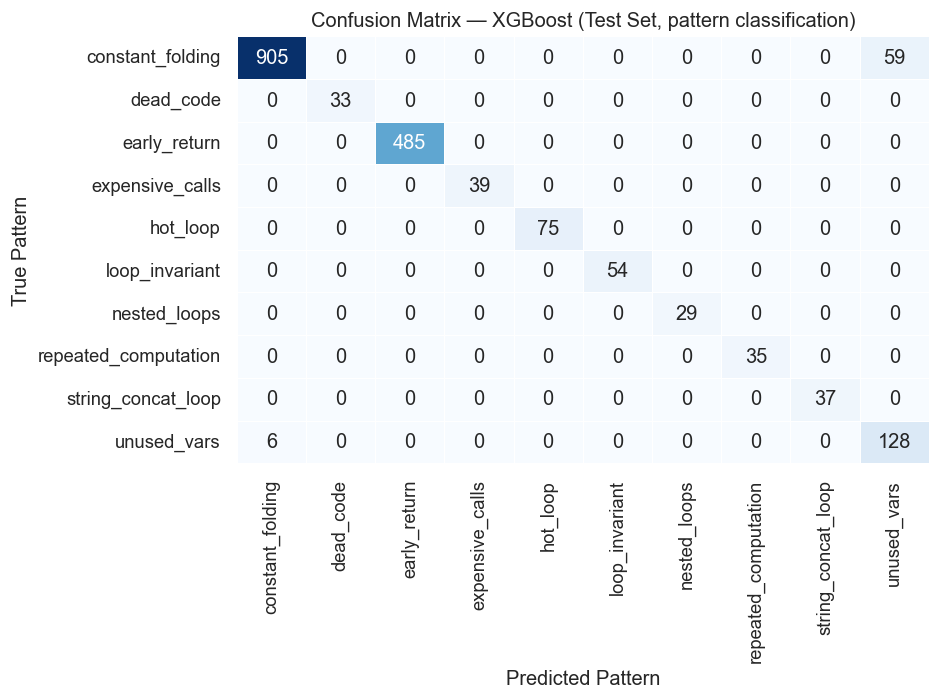

In [10]:
cm = confusion_matrix(y_test, y_pred_test)
n_classes = cm.shape[0] 

labels = list(le_pattern.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, ax=ax,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.4, linecolor="white", cbar=False
)
ax.set_title(f"Confusion Matrix — {best_model_name} (Test Set, pattern classification)", fontsize=12)
ax.set_xlabel("Predicted Pattern")
ax.set_ylabel("True Pattern")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "confusion_matrix_patterns.png"), dpi=150)
plt.show()

## 10. Contingency Matrix — Cluster × Pattern (Test Set)

Uses **test-set indices only** to avoid shape mismatch.
Shows which patterns dominate each cluster — used for semantic naming.


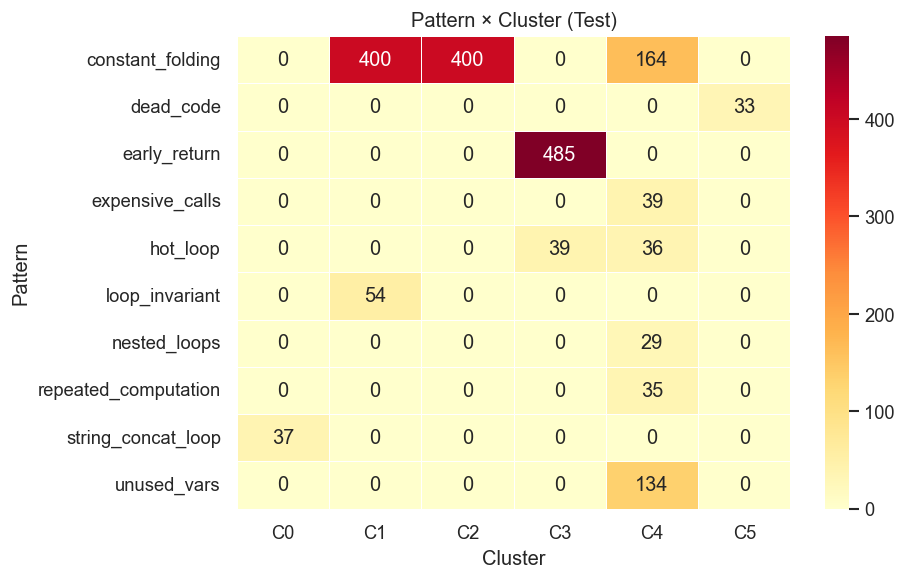

In [11]:
# Contingency (Pattern × Cluster)

clusters = sorted(np.unique(X_test_raw["cluster"]))
patterns = sorted(np.unique(y_test))

cm_cont = contingency_matrix(
    y_test,
    X_test_raw["cluster"].values.astype(int)
)

# safer row labels
if len(labels) == len(patterns):
    row_labels = labels
else:
    row_labels = [f"P{i}" for i in patterns]

col_labels = [f"C{i}" for i in clusters]

cont_df = pd.DataFrame(
    cm_cont,
    index=row_labels,
    columns=col_labels
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cont_df,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.4
)

plt.title("Pattern × Cluster (Test)")
plt.xlabel("Cluster")
plt.ylabel("Pattern")

plt.tight_layout()

plt.savefig(
    os.path.join(PLOTS_DIR, "contingency_pattern_cluster.png"),
    dpi=150
)

plt.show()

## 11. Feature Importance

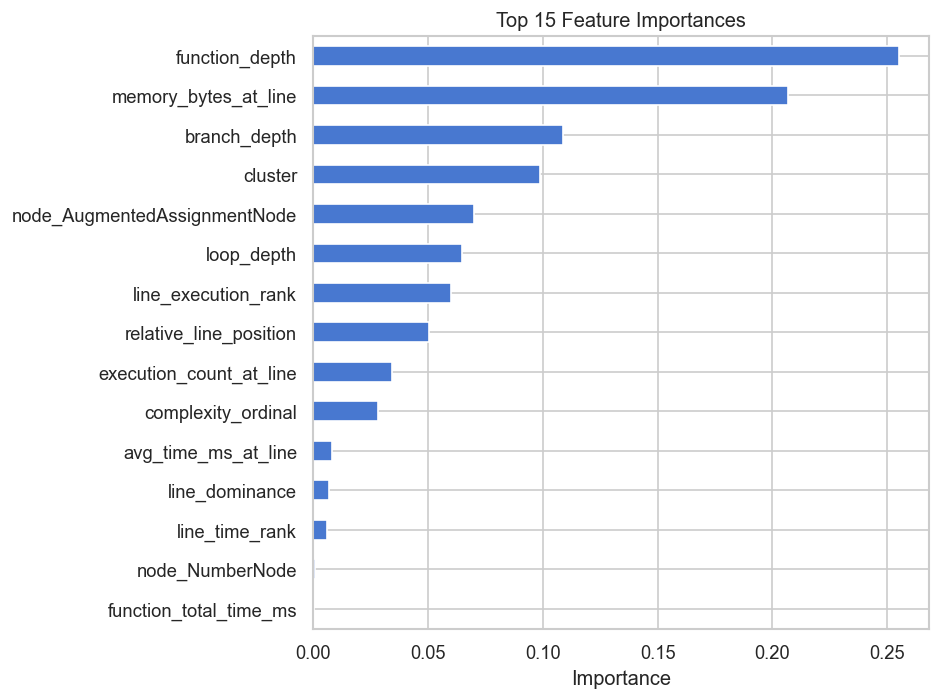


Top 10 features:
 complexity_ordinal              0.0282
execution_count_at_line         0.0346
relative_line_position          0.0504
line_execution_rank             0.0599
loop_depth                      0.0650
node_AugmentedAssignmentNode    0.0701
cluster                         0.0989
branch_depth                    0.1087
memory_bytes_at_line            0.2066
function_depth                  0.2553
dtype: float32


In [12]:
# Feature Importance

if hasattr(best_model, "feature_importances_"):
    imp = best_model.feature_importances_
    feat_imp = pd.Series(
        imp,
        index=X_raw.columns
    ).sort_values()
    plt.figure(figsize=(8,6))
    feat_imp.tail(15).plot(
        kind="barh"
    )
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PLOTS_DIR, "feature_importance_pattern.png"),
        dpi=150
    )
    plt.show()
    print("\nTop 10 features:\n",feat_imp.tail(10).round(4))

## 12. Semantic Cluster Naming

In [13]:
pattern = meta["pattern"].values                             
y       = meta["cluster"].values.astype(int)             

cm_full = contingency_matrix(pattern, y)
pattern_labels_full = sorted(np.unique(pattern))
FINAL_K = len(np.unique(y))                                 

cm_full_df = pd.DataFrame(
    cm_full,
    index=pattern_labels_full,
    columns=[f"C{i}" for i in range(FINAL_K)]
)

# Dominant pattern per cluster
dominant = cm_full_df.idxmax(axis=0)
print("Dominant pattern per cluster:")
print(dominant.to_string())

Dominant pattern per cluster:
C0    string_concat_loop
C1      constant_folding
C2      constant_folding
C3          early_return
C4      constant_folding
C5             dead_code


In [14]:
CLUSTER_NAMES = {
    0: "string_builder_refactor",   
    1: "hoist_and_fold",           
    2: "pure_constant_fold",       
    3: "guard_clause_exit",         
    4: "runtime_cost_reduction",    
    5: "dead_code_elimination",     
}

print("\nCluster name map:")
for k, v in CLUSTER_NAMES.items():
    print(f"  {k} → {v}")

# Save name map
import json
name_map_path = os.path.join(MODELS_DIR, f"cluster_names_k{FINAL_K}.json")  # ← FINAL_K
with open(name_map_path, "w") as f:
    json.dump(CLUSTER_NAMES, f, indent=2)
print(f"\nSaved: cluster names")


Cluster name map:
  0 → string_builder_refactor
  1 → hoist_and_fold
  2 → pure_constant_fold
  3 → guard_clause_exit
  4 → runtime_cost_reduction
  5 → dead_code_elimination

Saved: cluster names


## 13. Model Comparison Summary

In [15]:
rf_pred_test  = rf_search.best_estimator_.predict(X_test_raw)
rf_test_f1    = f1_score(y_test, rf_pred_test, average="weighted")

xgb_pred_test = xgb_search.best_estimator_.predict(X_test_raw)
xgb_test_f1   = f1_score(y_test, xgb_pred_test, average="weighted")

results = {
    "RandomForest": {
        "CV F1 (mean)": rf_search.best_score_,
        "Val F1"      : val_f1,
        "Test F1"     : rf_test_f1,
    },
    "XGBoost": {
        "CV F1 (mean)": xgb_search.best_score_,
        "Val F1"      : val_f1_xgb,
        "Test F1"     : test_f1,
    },
}

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
display(results_df.round(4))

best_model_name = results_df["Test F1"].idxmax()
test_f1         = results_df.loc[best_model_name, "Test F1"]
print(f"\nBest model: {best_model_name} (Test F1: {test_f1:.4f})")


Model Comparison:


,CV F1 (mean),Val F1,Test F1
RandomForest,0.9716,0.9655,0.9627
XGBoost,0.9770,0.9715,0.9679



Best model: XGBoost (Test F1: 0.9679)


## 14. Save Best Model

In [16]:
model_path = os.path.join(MODELS_DIR, f"classifier_{best_model_name.lower()}_k{FINAL_K}.pkl")
joblib.dump(best_model, model_path)
print(f"Saved model ")
print(f"Saved names ")


Saved model 
Saved names 
